# Olist E‑commerce Analytics (SQL → Python)

This notebook builds a clean **order-level analytical base** in SQL (views), validates data quality, and prepares a modeling-ready dataset for downstream work in Python (RFM / CLV / churn / sentiment).

## Notebook structure
- **0. Setup**: imports and database connection
- **1. Clean analytical base (SQL views)**: order revenue, payments, reviews, categories, and `v_order_fact`
- **2. Data structure & data quality**
  - **2.1 System audit** (`v_order_fact`): status funnel, payment coverage, revenue coverage
  - **2.2 Modeling audit** (`v_order_fact_delivered`): missingness, type fixes, outliers, transformations

> Grain: **1 row = 1 order** (order_id).  
> Customer analytics (RFM/CLV/churn) should use **customer_unique_id** (true customer identifier).

## 0. Setup

Load Python libraries used throughout the notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deep_translator import GoogleTranslator
import pymysql

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

## 1. Clean analytical base (SQL views)

Goal: create **order-level** views that aggregate one-to-many tables (items, payments, reviews) to **one row per order**.

Views created in this section:
- `v_order_revenue`
- `v_order_payments`
- `v_order_reviews` (latest review per order)
- `v_order_main_category` (dominant category by item count)
- `v_order_category_type` (single vs multi-category)
- `v_order_all_categories` (all categories as a comma-separated list)
- `v_order_main_category_revenue` (dominant category by revenue)
- `v_order_fact` (joins everything to the `orders` table)

In [5]:
## SQL Connection
conn = pymysql.connect(database = "olist", user = "root", password = "160510")
cursor = conn.cursor()

First, let's examine the tables in the database.

In [7]:
cursor.execute("SHOW TABLES FROM olist;")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

customers
geolocation
order_items
order_payments
order_reviews
orders
product_categories
products
sellers
v_order_all_categories
v_order_category_type
v_order_fact
v_order_fact_delivered
v_order_main_category
v_order_main_category_revenue
v_order_payments
v_order_revenue
v_order_reviews


In [11]:
pd.read_sql("SELECT * FROM customers LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\409707472.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM customers LIMIT 10", conn)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP
5,0004164d20a9e969af783496f3408652,104bdb7e6a6cdceaa88c3ea5fa6b2b93,13272,valinhos,SP
6,000419c5494106c306a97b5635748086,14843983d4a159080f6afe4b7f346e7c,24220,niteroi,RJ
7,00046a560d407e99b969756e0b10f282,0b5295fc9819d831f68eb0e9a3e13ab7,20540,rio de janeiro,RJ
8,00050bf6e01e69d5c0fd612f1bcfb69c,e3cf594a99e810f58af53ed4820f25e5,98700,ijui,RS
9,000598caf2ef4117407665ac33275130,7e0516b486e92ed3f3afdd6d1276cfbd,35540,oliveira,MG


In [13]:
pd.read_sql("SELECT * FROM geolocation LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\1850344455.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM geolocation LIMIT 10", conn)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.5456,-46.6393,sao paulo,SP
1,1046,-23.5461,-46.6448,sao paulo,SP
2,1046,-23.5461,-46.6430,sao paulo,SP
3,1041,-23.5444,-46.6395,sao paulo,SP
4,1035,-23.5416,-46.6416,sao paulo,SP
5,1012,-23.5478,-46.6354,são paulo,SP
6,1047,-23.5463,-46.6412,sao paulo,SP
7,1013,-23.5469,-46.6343,sao paulo,SP
8,1029,-23.5438,-46.6343,sao paulo,SP
9,1011,-23.5476,-46.6360,sao paulo,SP


In [15]:
pd.read_sql("SELECT * FROM order_items LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\4236510622.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM order_items LIMIT 10", conn)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.9900,12.7900
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.9000,18.1400
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.9000,12.6900
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.9000,11.8500
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.0000,70.7500
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.9500,11.6500
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.9900,11.4000


In [17]:
pd.read_sql("SELECT * FROM order_payments LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\1102294753.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM order_payments LIMIT 10", conn)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.1900
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.8300
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.8700
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.7800
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.0400
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,boleto,1,34.5900
6,00054e8431b9d7675808bcb819fb4a32,1,credit_card,1,31.7500
7,000576fe39319847cbb9d288c5617fa6,1,credit_card,10,880.7500
8,0005a1a1728c9d785b8e2b08b904576c,1,credit_card,3,157.6000
9,0005f50442cb953dcd1d21e1fb923495,1,credit_card,1,65.3900


In [19]:
pd.read_sql("SELECT * FROM order_reviews LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2323780491.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM order_reviews LIMIT 10", conn)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0001239bc1de2e33cb583967c2ca4c67,fc046d7776171871436844218f817d7d,5,,,2018-03-20,2018-03-20 18:36:04
1,0001cc6860aeaf5b9017fe4131a52e62,d4665434b01caa9dc3e3e78b3eb3593e,5,,,2018-06-22,2018-06-26 13:51:29
2,00020c7512a52e92212f12d3e37513c0,e28abf2eb2f1fbcbdc2dd0cd9a561671,5,Entrega rápida!,A entrega foi super rápida e o pendente é lind...,2018-04-25,2018-04-26 14:55:36
3,00032b0141443497c898b3093690af51,04fb47576993a3cb0c12d4b25eab6e4e,5,,,2017-05-30,2017-06-01 23:28:55
4,00034d88989f9a4c393bdcaec301537f,5f358d797a49fe2f24352f73426215f6,5,,,2017-08-12,2017-08-13 19:56:53
5,000359bceee1b6fe876b30d35b5f9ef2,97868e4c884bc85f4501ae0a66181cc9,5,,,2018-02-06,2018-02-06 20:54:37
6,00041b1f51e77a663df6db3f539d694f,998b1beee068744ac833dd8b31944623,1,,,2018-05-24,2018-05-24 12:45:38
7,00046a69550325aea5fb89f65c7387f2,9fbda7367628952bc36c3512c46d887b,5,SUPER RECOMENDO,"GOSTEI DA CAPINHA DE CELULAR, VEIO COMO EU ESP...",2018-07-01,2018-07-02 12:32:24
8,0005534973388c830bb858cfba83b17b,a589caa6892ceacc6bbf2f8cc30a8ad4,5,,otimo produto. prazo cumprido. sabor tambem mu...,2017-09-01,2017-09-02 13:04:08
9,00055e36e9608fe969231e551983a69c,f5fea26ab547eec920e6f8ecdc5c37e4,5,,O produto foi entregue muito antes do esperado...,2017-11-25,2017-11-27 11:37:22


In [21]:
pd.read_sql("SELECT * FROM orders LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\818585998.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM orders LIMIT 10", conn)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17
5,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 03:55:27,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06
6,00054e8431b9d7675808bcb819fb4a32,32e2e6ab09e778d99bf2e0ecd4898718,delivered,2017-12-10 11:53:48,2017-12-10 12:10:31,2017-12-12 01:07:48,2017-12-18 22:03:38,2018-01-04
7,000576fe39319847cbb9d288c5617fa6,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:27,2018-07-05 16:35:48,2018-07-05 12:15:00,2018-07-09 14:04:07,2018-07-25
8,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,2018-03-20 18:35:21,2018-03-28 00:37:42,2018-03-29 18:17:31,2018-03-29
9,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,delivered,2018-07-02 13:59:39,2018-07-02 14:10:56,2018-07-03 14:25:00,2018-07-04 17:28:31,2018-07-23


In [23]:
pd.read_sql("SELECT * FROM products LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\3534748766.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM products LIMIT 10", conn)


,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,53,596,6,300.0000,20.0000,16.0000,16.0000
1,00088930e925c41fd95ebfe695fd2655,automotivo,56,752,4,1225.0000,55.0000,10.0000,26.0000
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,50,266,2,300.0000,45.0000,15.0000,35.0000
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,25,364,3,550.0000,19.0000,24.0000,12.0000
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,48,613,4,250.0000,22.0000,11.0000,15.0000
5,0011c512eb256aa0dbbb544d8dffcf6e,automotivo,58,177,1,100.0000,16.0000,15.0000,16.0000
6,00126f27c813603687e6ce486d909d01,cool_stuff,42,2461,1,700.0000,25.0000,5.0000,15.0000
7,001795ec6f1b187d37335e1c4704762e,consoles_games,53,274,1,600.0000,30.0000,20.0000,20.0000
8,001b237c0e9bb435f2e54071129237e9,cama_mesa_banho,42,253,1,6000.0000,40.0000,4.0000,30.0000
9,001b72dfd63e9833e8c02742adf472e3,moveis_decoracao,45,520,3,600.0000,26.0000,8.0000,22.0000


In [25]:
pd.read_sql("SELECT * FROM product_categories LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2356259404.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM product_categories LIMIT 10", conn)


,product_category_name,product_category_name_english
0,agro_industria_e_comercio,agro_industry_and_commerce\r
1,alimentos,food\r
2,alimentos_bebidas,food_drink\r
3,artes,art\r
4,artes_e_artesanato,arts_and_craftmanship\r
5,artigos_de_festas,party_supplies\r
6,artigos_de_natal,christmas_supplies\r
7,audio,audio\r
8,automotivo,auto\r
9,bebes,baby\r


In [27]:
pd.read_sql("SELECT * FROM sellers LIMIT 10", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\442600753.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM sellers LIMIT 10", conn)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,9080,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,29156,cariacica,ES
2,001e6ad469a905060d959994f1b41e4f,24754,sao goncalo,RJ
3,002100f778ceb8431b7a1020ff7ab48f,14405,franca,SP
4,003554e2dce176b5555353e4f3555ac8,74565,goiania,GO
5,004c9cd9d87a3c30c522c48c4fc07416,14940,ibitinga,SP
6,00720abe85ba0859807595bbf045a33b,7070,guarulhos,SP
7,00ab3eff1b5192e5f1a63bcecfee11c8,4164,sao paulo,SP
8,00d8b143d12632bad99c0ad66ad52825,30170,belo horizonte,MG
9,00ee68308b45bc5e2660cd833c3f81cc,3333,sao paulo,SP


### 1.1. Order revenue (items aggregate)

In [29]:
q_order_revenue = """CREATE OR REPLACE VIEW v_order_revenue AS 
SELECT
	order_id,
    SUM(price) AS total_price,
    SUM(freight_value) AS total_freight,
    SUM(price + freight_value) AS total_revenue,
    COUNT(*) AS item_count
FROM order_items
GROUP BY order_id;"""

cursor.execute(q_order_revenue)
conn.commit()

In [31]:
pd.read_sql("SELECT * FROM v_order_revenue LIMIT 5", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2927306386.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_revenue LIMIT 5", conn)


,order_id,total_price,total_freight,total_revenue,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.9000,13.2900,72.1900,1
1,00018f77f2f0320c557190d7a144bdd3,239.9000,19.9300,259.8300,1
2,000229ec398224ef6ca0657da4fc703e,199.0000,17.8700,216.8700,1
3,00024acbcdf0a6daa1e931b038114c75,12.9900,12.7900,25.7800,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.9000,18.1400,218.0400,1


### 1.2. Payment Summary (Payments Aggregate)

In [34]:
q_payments = """CREATE OR REPLACE VIEW v_order_payments AS
SELECT
  order_id,
  SUM(payment_value) AS total_payment,
  MAX(payment_installments) AS max_installments,
  COUNT(*) AS payment_count
FROM order_payments
GROUP BY order_id;"""

cursor.execute(q_payments)
conn.commit() 

In [36]:
pd.read_sql("SELECT * FROM v_order_payments LIMIT 5", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\485157862.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_payments LIMIT 5", conn)


,order_id,total_payment,max_installments,payment_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.1900,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.8300,3,1
2,000229ec398224ef6ca0657da4fc703e,216.8700,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.7800,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.0400,3,1


### 1.3. Review summary (order-level)

Our goal is to receive the latest feedback on every order.

In [39]:
q_order_reviews = """CREATE OR REPLACE VIEW v_order_reviews AS
SELECT
	order_id,
    review_score,
    review_comment_title,
    review_comment_message,
    review_creation_date
FROM(
	SELECT
		order_id,
		review_score,
		review_comment_title,
		review_comment_message,
		review_creation_date,
		ROW_NUMBER() OVER w AS row_num
	FROM order_reviews
	WINDOW w AS (PARTITION BY order_id ORDER BY review_creation_date DESC)) a
WHERE a.row_num = 1;"""

cursor.execute(q_order_reviews)
conn.commit() 

In [41]:
pd.read_sql("SELECT * FROM v_order_reviews LIMIT 5", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\433348333.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_reviews LIMIT 5", conn)


,order_id,review_score,review_comment_title,review_comment_message,review_creation_date
0,00010242fe8c5a6d1ba2dd792cb16214,5,,"Perfeito, produto entregue antes do combinado.",2017-09-21
1,00018f77f2f0320c557190d7a144bdd3,4,,,2017-05-13
2,000229ec398224ef6ca0657da4fc703e,5,,Chegou antes do prazo previsto e o produto sur...,2018-01-23
3,00024acbcdf0a6daa1e931b038114c75,4,,,2018-08-15
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,,Gostei pois veio no prazo determinado .,2017-03-02


### 1.4. Product Category

The most dominant category in the order.

In [44]:
q_order_main_cat = """CREATE OR REPLACE VIEW v_order_main_category AS
SELECT
  t.order_id,
  pc.product_category_name_english AS product_category_name,
  t.item_count
FROM (
  SELECT
    oi.order_id,
    p.product_category_name,
    COUNT(*) AS item_count,
    ROW_NUMBER() OVER (
      PARTITION BY oi.order_id
      ORDER BY COUNT(*) DESC, p.product_category_name
    ) AS rn
  FROM order_items oi
  JOIN products p ON p.product_id = oi.product_id
  GROUP BY oi.order_id, p.product_category_name
) t
JOIN product_categories pc
  ON pc.product_category_name = t.product_category_name
WHERE t.rn = 1;"""

cursor.execute(q_order_main_cat)
conn.commit()

In [46]:
pd.read_sql("SELECT * FROM v_order_main_category LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2888135285.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_main_category LIMIT 10;", conn)


,order_id,product_category_name,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff\r,1
1,00018f77f2f0320c557190d7a144bdd3,pet_shop\r,1
2,000229ec398224ef6ca0657da4fc703e,furniture_decor\r,1
3,00024acbcdf0a6daa1e931b038114c75,perfumery\r,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools\r,1
5,00048cc3ae777c65dbb7d2a0634bc1ea,housewares\r,1
6,00054e8431b9d7675808bcb819fb4a32,telephony\r,1
7,000576fe39319847cbb9d288c5617fa6,garden_tools\r,1
8,0005a1a1728c9d785b8e2b08b904576c,health_beauty\r,1
9,0005f50442cb953dcd1d21e1fb923495,books_technical\r,1


Is the order a single category or a mixed order?

In [49]:
q_order_cat_type = """CREATE OR REPLACE VIEW v_order_category_type AS
SELECT
	oi.order_id,
    COUNT(DISTINCT p.product_category_name) AS category_count,
    CASE
		WHEN COUNT(DISTINCT p.product_category_name) = 1 THEN 'Single'
        ELSE 'Multi'
	END AS order_type
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
GROUP BY oi.order_id;"""

cursor.execute(q_order_cat_type)
conn.commit()

In [51]:
pd.read_sql("SELECT * FROM v_order_category_type LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\534171180.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_category_type LIMIT 10;", conn)


,order_id,category_count,order_type
0,00010242fe8c5a6d1ba2dd792cb16214,1,Single
1,00018f77f2f0320c557190d7a144bdd3,1,Single
2,000229ec398224ef6ca0657da4fc703e,1,Single
3,00024acbcdf0a6daa1e931b038114c75,1,Single
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,Single
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,Single
6,00054e8431b9d7675808bcb819fb4a32,1,Single
7,000576fe39319847cbb9d288c5617fa6,1,Single
8,0005a1a1728c9d785b8e2b08b904576c,1,Single
9,0005f50442cb953dcd1d21e1fb923495,1,Single


All categories in the Order.

In [54]:
q_all_cats = """CREATE OR REPLACE VIEW v_order_all_categories AS
SELECT
	oi.order_id,
    GROUP_CONCAT(DISTINCT pc.product_category_name_english
				ORDER BY pc.product_category_name_english
                SEPARATOR ',') AS categories
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
JOIN product_categories pc ON pc.product_category_name = p.product_category_name
GROUP BY oi.order_id;"""

cursor.execute(q_all_cats)
conn.commit()

In [56]:
pd.read_sql("SELECT * FROM v_order_all_categories LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\1961160998.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_all_categories LIMIT 10;", conn)


,order_id,categories
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff\r
1,00018f77f2f0320c557190d7a144bdd3,pet_shop\r
2,000229ec398224ef6ca0657da4fc703e,furniture_decor\r
3,00024acbcdf0a6daa1e931b038114c75,perfumery\r
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools\r
5,00048cc3ae777c65dbb7d2a0634bc1ea,housewares\r
6,00054e8431b9d7675808bcb819fb4a32,telephony\r
7,000576fe39319847cbb9d288c5617fa6,garden_tools\r
8,0005a1a1728c9d785b8e2b08b904576c,health_beauty\r
9,0005f50442cb953dcd1d21e1fb923495,books_technical\r


Expenditure-Based Main Category

In [59]:
q_main_cat_rev = """CREATE OR REPLACE VIEW v_order_main_category_revenue AS
SELECT
  order_id,
  pc.product_category_name_english AS product_category_name,
  revenue
FROM (
  SELECT
    oi.order_id,
    p.product_category_name,
    SUM(oi.price + oi.freight_value) AS revenue,
    ROW_NUMBER() OVER (
      PARTITION BY oi.order_id
      ORDER BY SUM(oi.price + oi.freight_value) DESC, p.product_category_name
    ) AS row_num
  FROM order_items oi
  JOIN products p ON p.product_id = oi.product_id
  GROUP BY oi.order_id, p.product_category_name
) t
JOIN product_categories pc ON pc.product_category_name = t.product_category_name
WHERE row_num = 1;"""

cursor.execute(q_main_cat_rev)
conn.commit()

In [61]:
pd.read_sql("SELECT * FROM v_order_main_category_revenue LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2606688981.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_main_category_revenue LIMIT 5;", conn)


,order_id,product_category_name,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff\r,72.1900
1,00018f77f2f0320c557190d7a144bdd3,pet_shop\r,259.8300
2,000229ec398224ef6ca0657da4fc703e,furniture_decor\r,216.8700
3,00024acbcdf0a6daa1e931b038114c75,perfumery\r,25.7800
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools\r,218.0400


### 1.5 Create Order Fact View

We will combine the tables we created above using aggregate methods with the order table. This will create a dataset on which we can train machine learning models.

In [66]:
q_fact = """
CREATE OR REPLACE VIEW v_order_fact AS
SELECT
  o.order_id,
  o.customer_id,
  c.customer_unique_id,
  o.order_status,

  -- timestamps
  o.order_purchase_timestamp      AS purchase_ts,
  o.order_approved_at             AS approved_ts,
  o.order_delivered_carrier_date  AS carrier_ts,
  o.order_delivered_customer_date AS delivered_ts,
  o.order_estimated_delivery_date AS est_delivery_ts,

  -- delivery KPIs
  CASE
    WHEN o.order_delivered_customer_date IS NULL THEN NULL
    ELSE DATEDIFF(o.order_delivered_customer_date, o.order_purchase_timestamp)
  END AS days_to_deliver,

  CASE
    WHEN o.order_delivered_customer_date IS NULL THEN NULL
    WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1
    ELSE 0
  END AS is_late,

  -- revenue (items)
  r.total_price,
  r.total_freight,
  r.total_revenue,
  r.item_count,

  -- payments
  p.total_payment,
  p.payment_count,
  p.max_installments,
  (p.total_payment - r.total_revenue) AS payment_minus_revenue,

  -- reviews (latest)
  rv.review_score,
  rv.review_comment_title,
  rv.review_comment_message,
  rv.review_creation_date,

  -- category features
  mc.product_category_name  AS main_category_by_item,
  mcr.product_category_name AS main_category_by_revenue,
  ct.category_count,
  ct.order_type,
  ac.categories AS all_categories,

  -- customers
  c.customer_city,
  c.customer_state

FROM orders o
LEFT JOIN customers c
  ON c.customer_id = o.customer_id
LEFT JOIN v_order_revenue r
  ON r.order_id = o.order_id
LEFT JOIN v_order_payments p
  ON p.order_id = o.order_id
LEFT JOIN v_order_reviews rv
  ON rv.order_id = o.order_id
LEFT JOIN v_order_main_category mc
  ON mc.order_id = o.order_id
LEFT JOIN v_order_main_category_revenue mcr
  ON mcr.order_id = o.order_id
LEFT JOIN v_order_category_type ct
  ON ct.order_id = o.order_id
LEFT JOIN v_order_all_categories ac
  ON ac.order_id = o.order_id;
"""
cursor.execute(q_fact)
conn.commit()

In [68]:
pd.read_sql("SELECT * FROM v_order_fact LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\821110113.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_fact LIMIT 5;", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7,0,58.9000,13.2900,72.1900,1,72.1900,1,2,0.0000,5,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16,0,239.9000,19.9300,259.8300,1,259.8300,1,3,0.0000,4,,,2017-05-13,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8,0,199.0000,17.8700,216.8700,1,216.8700,1,5,0.0000,5,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6,0,12.9900,12.7900,25.7800,1,25.7800,1,2,0.0000,4,,,2018-08-15,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25,0,199.9000,18.1400,218.0400,1,218.0400,1,3,0.0000,5,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


Some orders may not have payment statuses. When working with RFM/CLV/Churn, it's generally best to switch to a subset like "delivered".

In [70]:
q_fact_delivered = """CREATE OR REPLACE VIEW v_order_fact_delivered AS
SELECT *
FROM v_order_fact
WHERE order_status = 'delivered'
  AND delivered_ts IS NOT NULL;"""

cursor.execute(q_fact_delivered)
conn.commit()

In [72]:
pd.read_sql("SELECT * FROM v_order_fact_delivered LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\424419319.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM v_order_fact_delivered LIMIT 5;", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7,0,58.9000,13.2900,72.1900,1,72.1900,1,2,0.0000,5,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16,0,239.9000,19.9300,259.8300,1,259.8300,1,3,0.0000,4,,,2017-05-13,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8,0,199.0000,17.8700,216.8700,1,216.8700,1,5,0.0000,5,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6,0,12.9900,12.7900,25.7800,1,25.7800,1,2,0.0000,4,,,2018-08-15,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25,0,199.9000,18.1400,218.0400,1,218.0400,1,3,0.0000,5,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


In [74]:
pd.read_sql("""
SELECT
  COUNT(*) AS delivered_orders,
  COUNT(DISTINCT customer_id) AS distinct_customer_id,
  COUNT(DISTINCT customer_unique_id) AS distinct_customer_unique_id
FROM v_order_fact_delivered;
""", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2079634059.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("""


,delivered_orders,distinct_customer_id,distinct_customer_unique_id
0,96478,96478,93358


## 2. Data structure & data quality

Goal: validate that the analytical base is consistent and modeling-ready.

We do this in two passes:
1) **System audit** on `v_order_fact` (all statuses) to understand the platform funnel and data coverage.
2) **Modeling audit** on `v_order_fact_delivered` (delivered-only) for RFM/CLV/churn/sentiment workflows.

### 2.1 System audit (`v_order_fact`)

Questions answered:
- What is the **status distribution** (delivered vs canceled vs others)?
- Do we have **payments** for each status?
- Do we have **order_items / revenue** coverage for each status?

In [77]:
df_all = pd.read_sql("SELECT * FROM v_order_fact", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\4161294256.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact", conn)


In [78]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1.0000,72.1900,1.0000,2.0000,0.0000,5.0000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1.0000,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1.0000,259.8300,1.0000,3.0000,0.0000,4.0000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1.0000,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1.0000,216.8700,1.0000,5.0000,0.0000,5.0000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1.0000,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1.0000,25.7800,1.0000,2.0000,0.0000,4.0000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1.0000,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1.0000,218.0400,1.0000,3.0000,0.0000,5.0000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1.0000,Single,garden_tools\r,varzea paulista,SP


Let's look at the status distribution:

In [81]:
df_all["order_status"].value_counts(normalize=True)

order_status
delivered     0.9702
shipped       0.0111
canceled      0.0063
unavailable   0.0061
invoiced      0.0032
processing    0.0030
created       0.0001
approved      0.0000
Name: proportion, dtype: float64

97% of the orders in the dataset have been delivered to the customer. The dataset has a very low rate of canceled and undelivered orders.

In [83]:
## Payment vs Delivery

pd.crosstab(
    df_all["order_status"],
    df_all["total_payment"].notnull()
)

total_payment,False,True
order_status,,
approved,0,2
canceled,0,625
created,0,5
delivered,1,96477
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


* Payments were made despite 625 orders being cancelled.
* In churn analysis, we should not include revenue from canceled orders.
* We should also exclude this data from RFM analysis.

In [85]:
## Revenue Missing
df_all["total_revenue"].isnull().sum()

775

Let's check which statuses contain null observations regarding income.

In [92]:
df_all[df_all["total_revenue"].isnull()]["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

* There is revenue on all delivered orders. We can say that the join is correct.

In [95]:
# Customer-based cancellation rate:
cancel_rate = (
    df_all["order_status"].eq("canceled").groupby(df_all["customer_unique_id"]).mean()
)

cancel_rate.describe()

count   96096.0000
mean        0.0060
std         0.0758
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         1.0000
Name: order_status, dtype: float64

* On average, 0.60% of orders are cancelled for the customer.
* Low cancellation rate → successful operation.
* The cancellation rate is 0 for 50% and 75% of customers. Cancellation behavior is not widespread among customers in general.

Let's look at the order cancellation rate among customers who placed more than one order.

In [98]:
customer_stats = df_all.groupby("customer_unique_id").agg(
    total_orders = ("order_id", "count"),
    cancel_count = ("order_status", lambda x: (x=="canceled").sum())
)

In [99]:
customer_stats["cancel_ratio"] = (
    customer_stats["cancel_count"] / customer_stats["total_orders"]
)

In [102]:
customer_stats.groupby(
    customer_stats["total_orders"] > 1
)["cancel_ratio"].mean()

total_orders
False   0.0057
True    0.0141
Name: cancel_ratio, dtype: float64

* Repeat customers have a higher cancellation rate. There is approximately a 2.5-fold difference. Let's examine the average number of orders and average cancellation rates of repeat customers:

In [105]:
customer_stats["is_repeat"] = customer_stats["total_orders"] > 1

customer_stats.groupby("is_repeat").agg({
    "total_orders":"mean",
    "cancel_ratio":"mean"
})

,total_orders,cancel_ratio
is_repeat,,
False,1.0000,0.0057
True,2.1161,0.0141


Repeat customers exhibit slightly higher cancellation ratios compared to single-order customers (1.41% vs 0.57%).
However, overall cancellation rates remain very low across the platform, indicating operational stability.

### 2.2 Modeling dataset audit (`v_order_fact_delivered`)

This dataset is used for customer analytics and modeling, so we focus on:
- types (timestamps)
- missingness and handling strategy
- numeric distributions and outliers
- transformations for modeling (log/capping)

In [109]:
df = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_14580\2829680687.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)


In [110]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1,72.1900,1.0000,2.0000,0.0000,5.0000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1,259.8300,1.0000,3.0000,0.0000,4.0000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1,216.8700,1.0000,5.0000,0.0000,5.0000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1,25.7800,1.0000,2.0000,0.0000,4.0000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1,218.0400,1.0000,3.0000,0.0000,5.0000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


In [111]:
df.shape

(96478, 30)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96478 non-null  object        
 6   carrier_ts                96478 non-null  object        
 7   delivered_ts              96478 non-null  object        
 8   est_delivery_ts           96478 non-null  datetime64[ns]
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight     

In [113]:
# Let's correct the columns that should contain Datetime:
date_cols = ["approved_ts", "carrier_ts", "delivered_ts", "review_creation_date"]

for col in date_cols:
    n_zero = (df[col].astype(str).str.startswith("0000-00-00")).sum()
    print(col, n_zero)

approved_ts 14
carrier_ts 2
delivered_ts 8
review_creation_date 1


In [114]:
date_cols = ["approved_ts", "carrier_ts", "delivered_ts", "review_creation_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].isna().sum()

approved_ts               14
carrier_ts                 2
delivered_ts               8
review_creation_date    1108
dtype: int64

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96464 non-null  datetime64[ns]
 6   carrier_ts                96476 non-null  datetime64[ns]
 7   delivered_ts              96470 non-null  datetime64[ns]
 8   est_delivery_ts           96478 non-null  datetime64[ns]
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight     

Let's check for missing observations:

In [117]:
df.isnull().mean().sort_values(ascending=False)

main_category_by_item      0.0145
main_category_by_revenue   0.0143
all_categories             0.0140
review_creation_date       0.0115
review_score               0.0115
review_comment_title       0.0115
review_comment_message     0.0115
approved_ts                0.0001
days_to_deliver            0.0001
delivered_ts               0.0001
carrier_ts                 0.0000
payment_count              0.0000
total_payment              0.0000
payment_minus_revenue      0.0000
max_installments           0.0000
category_count             0.0000
order_type                 0.0000
customer_city              0.0000
order_id                   0.0000
customer_id                0.0000
item_count                 0.0000
total_revenue              0.0000
total_freight              0.0000
total_price                0.0000
is_late                    0.0000
est_delivery_ts            0.0000
purchase_ts                0.0000
order_status               0.0000
customer_unique_id         0.0000
customer_state

Let's fill the empty values ​​in the category columns with "unknown".

In [119]:
cat_cols = [
    "main_category_by_item",
    "main_category_by_revenue",
    "all_categories"
]

for col in cat_cols:
    df[col] = df[col].fillna("unknown")

Let's create a flag variable for the case where there is no review score. Then, let's fill any empty review score values ​​with 0.

In [121]:
df["has_review"] = df["review_score"].notnull().astype(int)

df["review_score"] = df["review_score"].fillna(0)

* Missing values are minimal (<1.5% across all variables).
* Categorical missing values were assigned as "unknown".
* Review-related missingness was handled by introducing a binary flag (has_review).
* Timestamp anomalies were coerced to NaT.

In [123]:
df.isnull().mean().sort_values(ascending=False).head(10)

review_creation_date     0.0115
review_comment_title     0.0115
review_comment_message   0.0115
approved_ts              0.0001
days_to_deliver          0.0001
delivered_ts             0.0001
carrier_ts               0.0000
max_installments         0.0000
payment_count            0.0000
total_payment            0.0000
dtype: float64

Let's remove the /r expressions from the observations in the category columns:


In [125]:
for c in cat_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.replace(r"\r|\n","",regex=True)
        .str.strip()
    )

In [126]:
df[df["category_count"] > 1].head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,has_review
72,002f98c0f7efd42638ed6100ca699b42,75fd1fb0bb511fc71ac2b2649c02b21b,2e875ea57961ad115cec13fef0920ae6,delivered,2017-08-04 09:19:10,2017-08-04 09:30:15,2017-08-04 18:09:47,2017-08-07 19:07:30,2017-09-05,3.0000,0,53.8900,39.7300,93.6200,2,93.6200,1.0000,9.0000,0.0000,5.0000,,,2017-08-08,toys,toys,2,Multi,"consoles_games,toys",porto alegre,RS,1
132,005d9a5423d47281ac463a968b3936fb,a2be07c22a9d2071f65b6770e47f540b,6204c4e582a95b6a350adf6988623bfb,delivered,2017-10-18 12:14:29,2017-10-18 12:28:16,2017-10-24 14:56:52,2017-10-27 19:19:43,2017-11-17,9.0000,0,99.9700,45.2800,145.2500,3,145.2600,1.0000,10.0000,0.0100,1.0000,,Ainda não recebi todos os produtos,2017-10-28,baby,baby,2,Multi,"baby,toys",sao jose do rio pardo,SP,1
479,014405982914c2cde2796ddcf0b8703d,2de342d6e5905a5a8bb3a991c855f3e2,e8d87ee946600f7753579a074fbd2d5d,delivered,2017-07-26 17:38:47,2017-07-26 17:50:17,2017-07-27 19:39:52,2017-07-31 15:53:33,2017-08-17,5.0000,0,49.2300,29.2000,78.4300,2,78.4300,1.0000,7.0000,0.0000,5.0000,,,2017-08-01,sports_leisure,sports_leisure,2,Multi,"perfumery,sports_leisure",mesquita,RJ,1
625,01b1a7fdae9ad1837d6ab861705a1fa5,a2da04a295c890e30103aeb5356163f0,1a871dc1de3ae88bf92c8d94ca34fa9f,delivered,2017-05-29 15:48:13,2017-05-29 16:02:58,2017-06-01 11:45:09,2017-06-07 14:07:04,2017-06-21,9.0000,0,108.9900,26.8500,135.8400,2,135.8400,1.0000,1.0000,0.0000,3.0000,,,2017-06-23,bed_bath_table,housewares,2,Multi,"bed_bath_table,housewares",valinhos,SP,1
676,01cce1175ac3c4a450e3a0f856d02734,6ec610172716519f13781b3068dde24b,07fe3cee40551d2377a917fb4f377714,delivered,2018-07-19 20:32:57,2018-07-19 20:43:14,2018-07-20 08:23:00,2018-07-21 16:27:44,2018-08-06,2.0000,0,96.2300,27.5100,123.7400,2,123.7400,1.0000,1.0000,0.0000,2.0000,Recebi só metade dos prod,Recebi metade dos produtos,2018-07-22,garden_tools,garden_tools,2,Multi,"garden_tools,stationery",sao paulo,SP,1


Let's examine the payment consistency:

In [128]:
df["payment_minus_revenue"].describe()

count   96477.0000
mean       -2.5977
std        31.9172
min     -3899.0000
25%         0.0000
50%         0.0000
75%         0.0000
max       182.8100
Name: payment_minus_revenue, dtype: float64

In [129]:
df.sort_values("payment_minus_revenue").head(5)

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,has_review
59172,9de73f3e6157169ad6c32b9f313c7dcb,eb7a157e8da9c488cd4ddc48711f1097,58483a1c055dfb600f57c5b867174542,delivered,2018-06-05 12:45:17,2018-06-05 14:31:37,2018-06-06 09:15:00,2018-06-12 09:54:46,2018-07-03,7.0000,0,3899.0000,135.4400,4034.4400,1,135.4400,1.0000,1.0000,-3899.0000,5.0000,,,2018-06-13,baby,baby,1,Single,baby,jundiai,SP,1
48482,80dfedb6d17bf23539beeef3c768f4d7,926b6a6fb8b6081e00b335edaf578d35,edf81e1f3070b9dac83ec83dacdbb9bc,delivered,2017-04-18 20:37:26,2017-04-18 20:50:13,2017-04-25 14:08:56,2017-05-04 14:13:36,2017-05-16,16.0000,0,3999.0000,195.7600,4194.7600,1,834.1000,1.0000,8.0000,-3360.6600,2.0000,,"comprei a maquina com 2 bastidores extras, ent...",2017-05-05,small_appliances,small_appliances,1,Single,small_appliances,brasilia,DF,1
91808,f398a143c0fe171d965db2096cf064cf,46bb3c0b1a65c8399d0363cefbcc4f37,7a96eb0a685f5c19b7dad29fc802aa64,delivered,2017-12-17 09:15:37,2017-12-17 09:30:27,2017-12-20 22:28:45,2017-12-23 12:50:01,2018-01-08,6.0000,0,3124.0000,173.4000,3297.4000,1,1113.9900,1.0000,1.0000,-2183.4100,5.0000,,,2017-12-24,health_beauty,health_beauty,1,Single,health_beauty,santa maria,RS,1
39554,6907ea7150759a085c8ed75a55aeb90d,e69714d6b494f7279512327ebcc01889,cad51aa032a0834a45c27586bce31d1c,delivered,2017-05-17 11:36:51,2017-05-17 13:04:02,2017-05-18 13:27:32,2017-05-22 10:31:38,2017-06-14,5.0000,0,2109.9000,40.9100,2150.8100,1,350.8100,1.0000,10.0000,-1800.0000,1.0000,,,2017-05-23,musical_instruments,musical_instruments,1,Single,musical_instruments,rio de janeiro,RJ,1
92158,f489949dbe23cf9313deb342913ece0c,6f241d5bbb142b6f764387c8c270645a,be74c431147c32ab2d7c7cef5e4a995f,delivered,2018-05-10 18:46:19,2018-05-11 09:40:13,2018-05-11 13:53:00,2018-05-21 16:49:52,2018-06-06,11.0000,0,1360.0200,76.4400,1436.4600,1,50.0000,1.0000,1.0000,-1386.4600,5.0000,Avaliçao,"100%, produto entregue antes do esperado.",2018-05-22,computers_accessories,computers_accessories,1,Single,computers_accessories,caxias do sul,RS,1


**Payment vs revenue consistency**

- In most orders, **total_payment ≈ total_revenue** (median difference is typically near 0).
- A small negative/positive mean difference can occur due to **discounts, rounding, or data-generation quirks** in the dataset.
- We treat large absolute gaps as anomalies and inspect them separately (e.g., `abs(payment_minus_revenue) > 5`).

In [131]:
df[df["payment_minus_revenue"] < 0].describe()

,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_creation_date,category_count,has_review
count,3076,3076,3076,3076,3076,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3076.0000,3038,3076.0000,3076.0000
mean,2017-12-14 04:48:10.196684032,2017-12-14 12:04:35.236020992,2017-12-17 09:25:41.901170432,2017-12-26 22:58:33.025357824,2018-01-07 19:27:04.447334400,12.7100,0.0718,149.8571,25.2396,175.0967,1.2711,92.6512,1.0000,1.8839,-82.4455,4.0078,2017-12-27 03:29:33.930217216,1.0241,0.9876
min,2016-10-04 13:22:56,2016-10-04 13:47:45,2016-10-10 15:45:44,2016-10-13 15:45:44,2016-11-23 00:00:00,1.0000,0.0000,2.2000,0.0000,9.5900,1.0000,0.0100,1.0000,1.0000,-3899.0000,0.0000,2016-10-18 00:00:00,1.0000,0.0000
25%,2017-08-15 11:17:13,2017-08-15 14:00:33.750000128,2017-08-17 16:24:51.249999872,2017-08-25 19:34:47.500000,2017-09-06 00:00:00,7.0000,0.0000,44.9900,14.1700,60.8600,1.0000,17.6750,1.0000,1.0000,-94.0625,3.0000,2017-08-26 00:00:00,1.0000,1.0000
50%,2017-12-26 15:23:59,2017-12-26 16:41:52,2017-12-28 17:02:11,2018-01-09 21:52:42,2018-01-24 00:00:00,10.0000,0.0000,84.9900,17.9050,104.7700,1.0000,43.6900,1.0000,1.0000,-48.2600,5.0000,2018-01-10 00:00:00,1.0000,1.0000
75%,2018-04-22 13:55:47.249999872,2018-04-24 18:30:44.750000128,2018-04-25 09:18:00,2018-05-03 22:00:06,2018-05-16 00:00:00,16.0000,0.0000,149.9925,26.5000,185.1900,1.0000,100.0000,1.0000,1.0000,-20.0000,5.0000,2018-05-04 00:00:00,1.0000,1.0000
max,2018-08-28 15:53:09,2018-08-29 03:10:17,2018-08-29 19:11:00,2018-08-31 00:14:30,2018-10-16 00:00:00,175.0000,1.0000,3999.0000,357.4800,4194.7600,21.0000,3195.7300,1.0000,24.0000,-0.0100,5.0000,2018-08-31 00:00:00,3.0000,1.0000
std,NaN,NaN,NaN,NaN,NaN,9.7636,0.2583,247.8999,24.0967,259.7651,0.8675,176.8185,0.0000,2.2453,159.1674,1.4188,NaN,0.1554,0.1105


In [132]:
df[df["payment_minus_revenue"] < 0][
    ["total_revenue","total_payment","payment_minus_revenue"]
].head()

,total_revenue,total_payment,payment_minus_revenue
35,70.5500,17.9200,-52.6300
158,192.4400,100.0000,-92.4400
212,32.0000,8.7500,-23.2500
251,50.5900,48.0500,-2.5400
266,85.8000,40.4600,-45.3400


Here we see a difference stemming from the discount coupons used when shopping on the e-commerce site.

In [134]:
# Gap / Revenue
df["gap_ratio"] = df["payment_minus_revenue"] / df["total_revenue"]
df[df["payment_minus_revenue"] < 0]["gap_ratio"].describe()

count   3076.0000
mean      -0.5151
std        0.3092
min       -1.0000
25%       -0.7876
50%       -0.5258
75%       -0.2434
max       -0.0000
Name: gap_ratio, dtype: float64

We avoid ratio-based metrics here because `payment_minus_revenue` can be near zero and make ratios unstable. Instead, we monitor the **absolute difference** and review extreme cases.

In [138]:
df["payment_ratio"] = df["total_payment"] / df["total_revenue"]
df["payment_ratio"].describe()

count   96477.0000
mean        0.9838
std         0.1062
min         0.0000
25%         1.0000
50%         1.0000
75%         1.0000
max         1.4134
Name: payment_ratio, dtype: float64

The average payout rate is 98%. The median is 100%.

In [145]:
df["discount_intensity"] = 1 - df["payment_ratio"]

In [150]:
# Discount rates per customer:
customer_discount = df.groupby("customer_unique_id")["discount_intensity"].mean()

Delivery Metrics Sanity Check

In [158]:
df["days_to_deliver"].describe()

count   96470.0000
mean       12.4968
std         9.5551
min         0.0000
25%         7.0000
50%        10.0000
75%        16.0000
max       210.0000
Name: days_to_deliver, dtype: float64

In [162]:
df[df["days_to_deliver"] < 0]

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,has_review,gap_ratio,payment_ratio,discount_intensity


Distribution Check

In [167]:
df["total_revenue"].describe(percentiles=[.01,.05,.95,.99])

count   96478.0000
mean      159.8268
std       218.7942
min         9.5900
1%         22.3800
5%         32.3800
50%       105.2800
95%       446.2320
99%      1052.3899
max     13664.0800
Name: total_revenue, dtype: float64

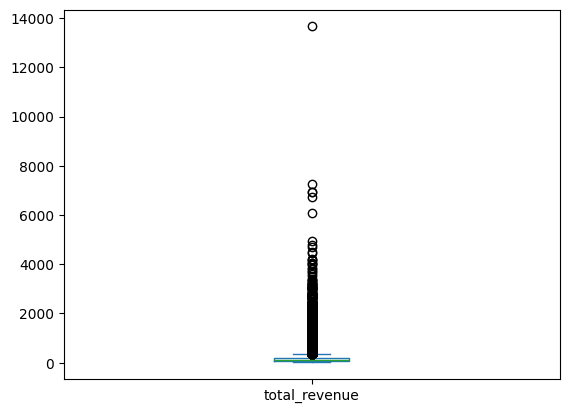

In [169]:
df["total_revenue"].plot.box()
plt.show()

Let's apply a logarithmic conversion to the total revenue:

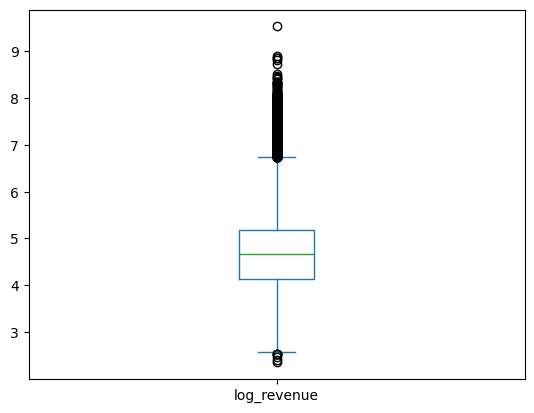

In [172]:
df["log_revenue"] = np.log1p(df["total_revenue"])

df["log_revenue"].plot.box()
plt.show()

* RFM scoring → raw revenue
* ML model → log revenue

Delivery Time

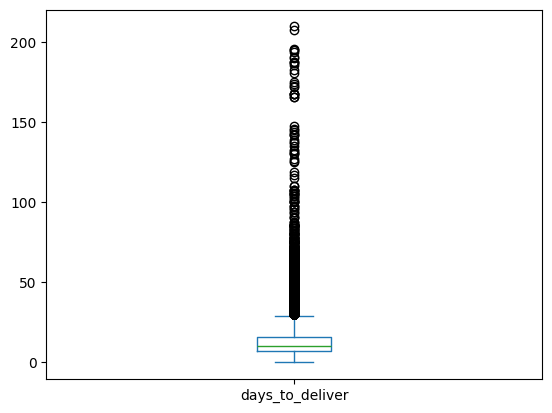

In [176]:
df["days_to_deliver"].plot.box()
plt.show()

In [178]:
df["days_to_deliver"].describe(percentiles=[.5,.75,.90,.95,.99])

count   96470.0000
mean       12.4968
std         9.5551
min         0.0000
50%        10.0000
75%        16.0000
90%        23.0000
95%        29.0000
99%        46.0000
max       210.0000
Name: days_to_deliver, dtype: float64

Let's cut the extreme ends at 99%.

In [181]:
upper = df["days_to_deliver"].quantile(0.99)
df["days_to_deliver_capped"] = df["days_to_deliver"].clip(upper=upper)

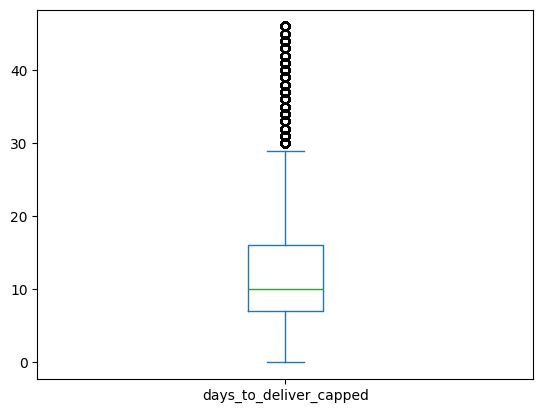

In [183]:
df["days_to_deliver_capped"].plot.box()
plt.show()

Let's look at the distribution of monetary values:

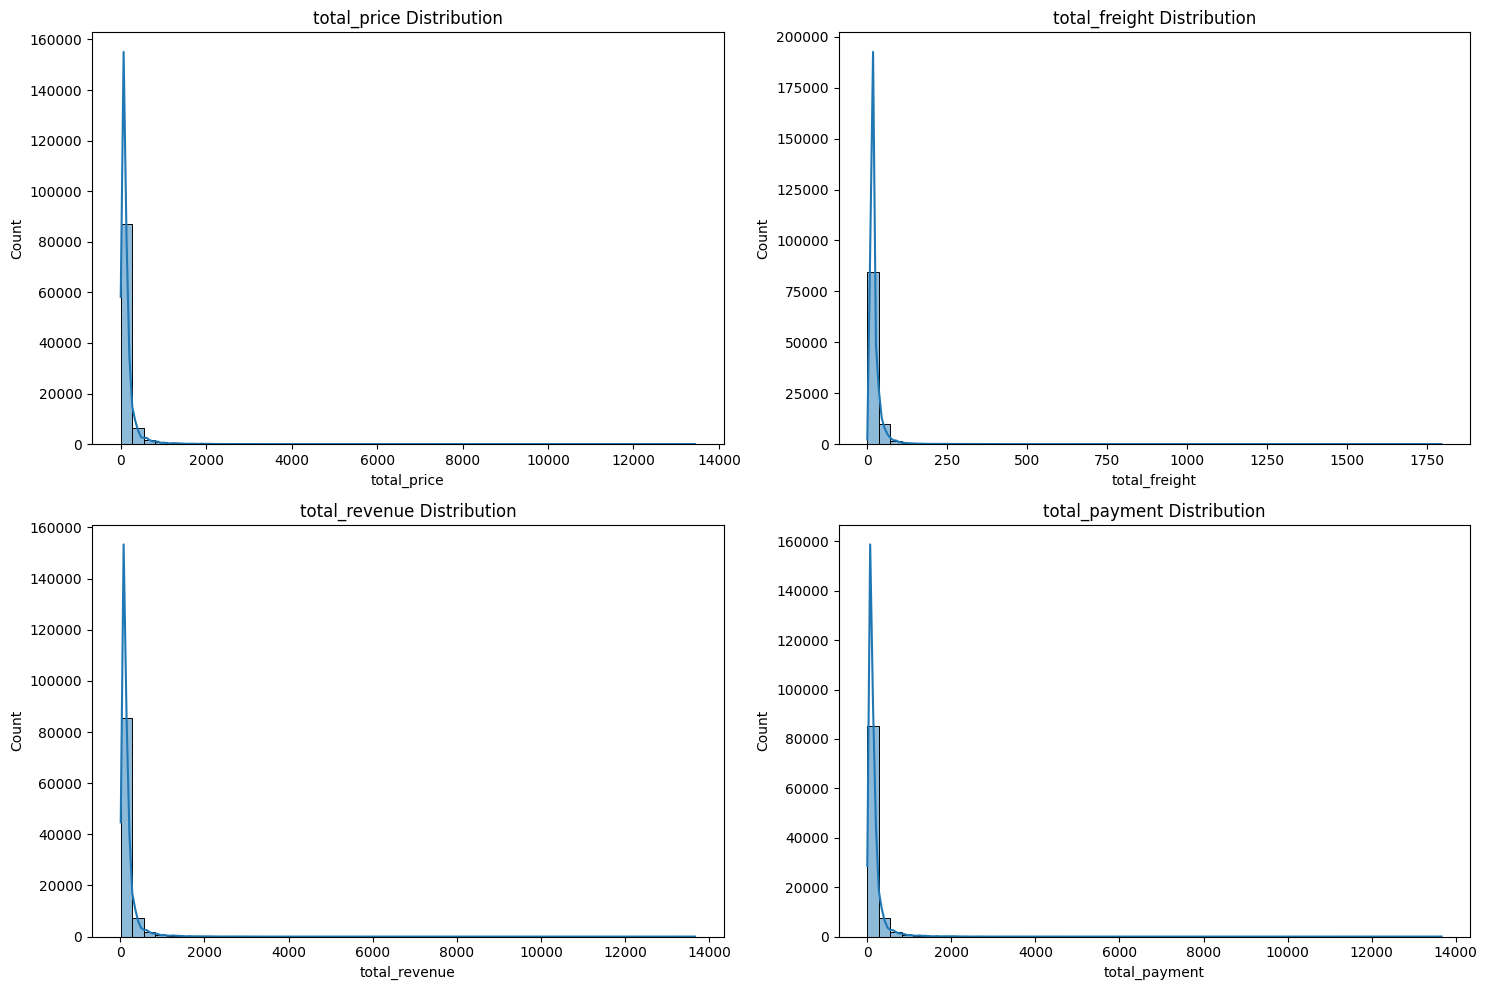

In [186]:
cols = [
    "total_price",
    "total_freight",
    "total_revenue",
    "total_payment"
]

plt.figure(figsize =(15,10))

for i, col in enumerate(cols,1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [187]:
log_cols = []
for col in cols:
    new_col = col.split("_")[1]
    log_cols.append(f"log_{new_col}")
    df[f"log_{new_col}"] = np.log1p(df[col])

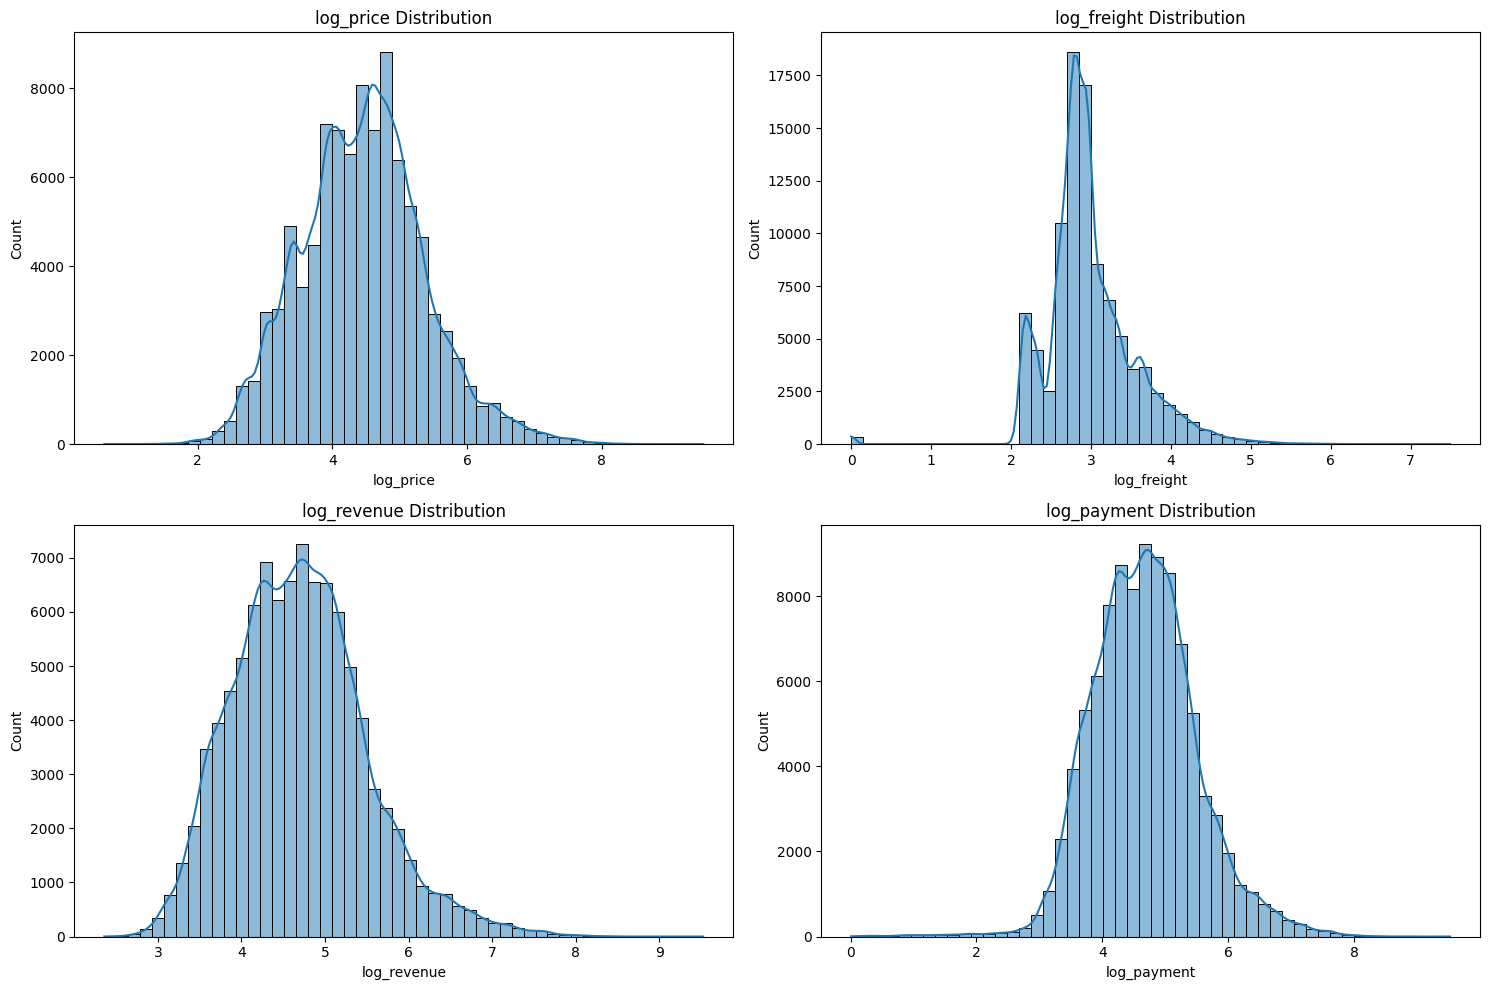

In [188]:
plt.figure(figsize =(15,10))

for i, col in enumerate(log_cols,1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

Temporal Coverage

In [190]:
df["purchase_ts"].min(), df["purchase_ts"].max()

(Timestamp('2016-09-15 12:16:38'), Timestamp('2018-08-29 15:00:37'))

Data covers from 2016-09-15 to 2018-08-29.

In [192]:
df.to_csv("v_order_fact_delivered_cleaned.csv")

In [193]:
df_all.to_csv("v_order_fact_cleaned.csv")

In [200]:
conn.close()

## Key takeaways from data quality checks

- `v_order_fact` confirms the system is largely healthy (high delivered rate, consistent payment coverage).
- Revenue is present for delivered orders; missing revenue is concentrated in non-delivered statuses.
- `v_order_fact_delivered` has **low missingness** (<1.5% in any field) and is suitable for modeling.
- Monetary variables are strongly right-skewed → use `log1p` for modeling stability.
- Delivery time has a long right tail → consider capping (e.g., 99th percentile) for robust features.

Next: In the next notebook, we will perform a comprehensive exploratory data analysis to better understand customer and order behavior before moving to feature engineering and modeling.